# Custom Normalization Layer - MaxNormDense

# SetUp

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


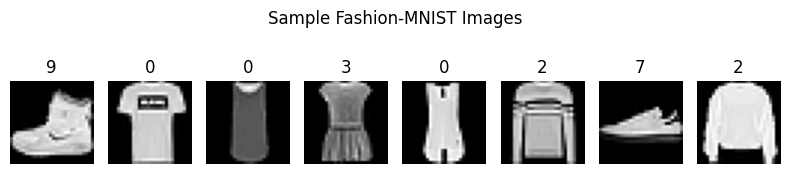

In [4]:
# Load and preprocess the data first
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

# Now proceed with plotting
plt.figure(figsize=(8, 2))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.suptitle("Sample Fashion-MNIST Images")
plt.tight_layout()
plt.show()

# Custom MaxNormDense Layer

In [5]:
class MaxNormDense(layers.Layer):
    def __init__(self, units, max_norm=1.0, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.max_norm = max_norm

    def build(self, input_shape):
        self.kernel = self.add_weight(
            shape=(int(input_shape[-1]), self.units),
            initializer="glorot_uniform",
            trainable=True,
            name="kernel"
        )
        self.bias = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            name="bias"
        )

    def call(self, inputs):
        clipped_kernel = tf.clip_by_norm(self.kernel, self.max_norm, axes=[0])
        return tf.matmul(inputs, clipped_kernel) + self.bias

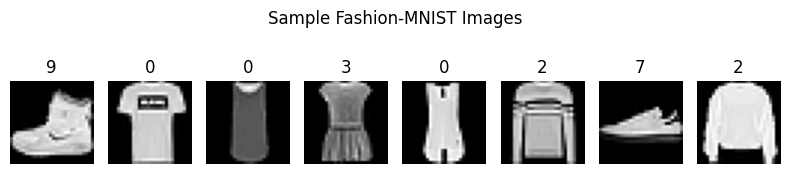

In [6]:
plt.figure(figsize=(8, 2))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.suptitle("Sample Fashion-MNIST Images")
plt.tight_layout()
plt.show()
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

# Model with MaxNormDense

In [7]:
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    MaxNormDense(256, max_norm=2.0),
    layers.Activation("relu"),
    MaxNormDense(128, max_norm=2.0),
    layers.Activation("relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Train and evaluate

In [8]:
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test), verbose=2)

Epoch 1/5
938/938 - 11s - 11ms/step - accuracy: 0.8256 - loss: 0.4939 - val_accuracy: 0.8552 - val_loss: 0.4041
Epoch 2/5
938/938 - 11s - 12ms/step - accuracy: 0.8674 - loss: 0.3604 - val_accuracy: 0.8638 - val_loss: 0.3778
Epoch 3/5
938/938 - 18s - 19ms/step - accuracy: 0.8808 - loss: 0.3258 - val_accuracy: 0.8666 - val_loss: 0.3663
Epoch 4/5
938/938 - 11s - 11ms/step - accuracy: 0.8876 - loss: 0.3033 - val_accuracy: 0.8606 - val_loss: 0.3685
Epoch 5/5
938/938 - 9s - 10ms/step - accuracy: 0.8948 - loss: 0.2824 - val_accuracy: 0.8806 - val_loss: 0.3363


# Plot training results

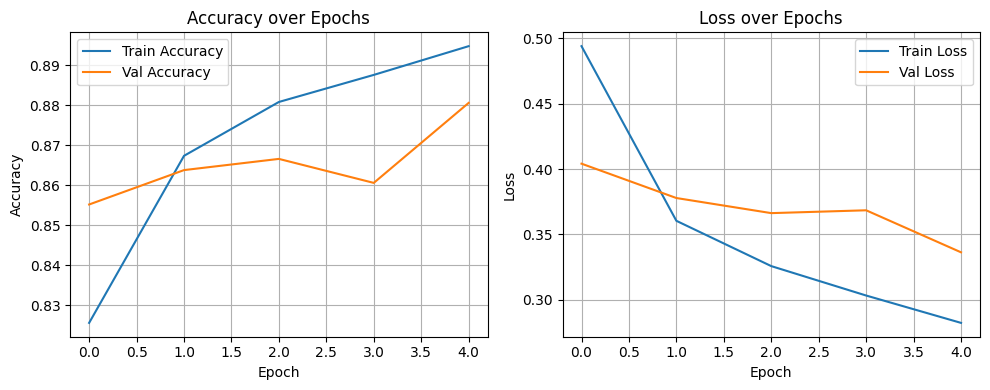

✅ MaxNormDense custom layer training complete.


In [9]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print("✅ MaxNormDense custom layer training complete.")